In [1]:
"""Smoke-test for the Rossmann store sales forecasting pipeline.

Generates a small synthetic dataset with a strong, easy-to-fit weekly pattern,
runs the full feature-engineering → nested CV pipeline, prints test-set metrics,
and plots real vs predicted sales for the last outer fold.

Usage: conda run -n rossmann python test_pipeline.py
"""

import os
import logging
import warnings

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import src.constants as C

from matplotlib import cm
from src import features
from src.preprocessing import drop_null_targets
from src.engine.cv import TimeSeriesCV
from src.engine.metrics import compute_metrics
from src.engine import utils, hypertuning

os.makedirs(C.LOG_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, 
                    filename=os.path.join(C.LOG_DIR, "test_pipeline.log"),
                    format="%(levelname)s  %(message)s")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

logger = logging.getLogger(__name__)




c:\Users\m_kal\Downloads\rossmann_store_sales\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Synthetic Data

Strong deterministic weekly + trend signal so the model can overfit easily and produce low errors.

In [2]:

cv_config = {
    "n_outer_splits":   C.N_OUTER_SPLITS,
    "n_inner_splits":   C.N_INNER_SPLITS,
    "forecast_horizon": 10, #C.FORECAST_HORIZON,
    "inner_train_size": 1000, #C.INNER_TRAIN_SIZE,
}

cv_config["outer_train_size"] = (cv_config["n_inner_splits"] + 1) * cv_config["forecast_horizon"] + cv_config["inner_train_size"]


study_config = {
    "storage_url":           C.STORAGE_URL,
    "n_trials":              C.NUM_TRIALS,
    "n_startup_trials":      C.NUM_STARTUP_TRIALS,
    "n_jobs":                C.NUM_JOBS,
    "seed":                  C.SEED,
    "xgb_constants":         C.XGB_CONSTANTS,
    "early_stopping_rounds": C.EARLY_STOPPING_ROUNDS,
    "num_boost_rounds":      C.NUM_BOOST_ROUNDS,
    "monitor_periods":       C.MONITOR_PERIODS,
    "hyperparameters":       C.HYPERPARAMETERS,
    "log_dir":               C.LOG_DIR,
}


In [3]:
""" Read the Rossmann store sales dataset and preprocess it for modeling. """
from src.preprocessing import preprocess_data, interpolate_closed_days, set_closed_to_zero


sales = pd.read_csv(r'C:\Users\m_kal\Downloads\datasets\rossmann-store-sales\train.csv')
stores = pd.read_csv(r'C:\Users\m_kal\Downloads\datasets\rossmann-store-sales\store.csv')

stores_to_use = [1, 2, 3, 4, 5, 6]
stores = stores[stores['Store'].isin(stores_to_use)]

df = preprocess_data(sales, stores)
df = interpolate_closed_days(df)

In [4]:
import xgboost as xgb
import pandas as pd
from src.engine.hypertuning import _objective
from optuna.trial import FixedTrial
from src.engine.target_transformer import TargetTransformer

FORECAST_HORIZON = 10
windows = ['7D', '14D', '30D', '60D']
lags    = [pd.DateOffset(days=i) for i in range(FORECAST_HORIZON * 3)] # lag 0 is the current value, lag 1 is the previous day, etc.
diffs   = [pd.DateOffset(days=i) for i in [3, 5, 7, 14, 30]]
horizon = pd.DateOffset(days=FORECAST_HORIZON) # We use this to shift the features by the forecast
                                               # horizon to align them with the target variable.

y = (df
     .set_index(['Store', 'Date'])
     ['Sales'])

X = (df
     .set_index(['Date'])
     .groupby('Store')
     .apply(lambda df: features.compute(df, lags, diffs, windows, horizon)))

trf = TargetTransformer(forecast_horizon=pd.DateOffset(days=-FORECAST_HORIZON),
                        anchor_col='lag_days_0').fit(X)

y = trf.transform(y)    # Transform the target variable to compute the forward difference
X = X.loc[y.index]      # Align features with the target variable by dropping any rows in X that don't have a corresponding target value in y.

inner_cv = TimeSeriesCV(n_splits=C.N_INNER_SPLITS,
                        train_size=C.INNER_TRAIN_SIZE,
                        test_size=C.INNER_TEST_SIZE)


# Values must fall within the bounds defined in C.HYPERPARAMETERS
params = {
    'max_depth': 6,
    'learning_rate': 1e-3,
    'subsample': 0.5,        # C.HYPERPARAMETERS bounds: [0.6, 1.0]
    'colsample_bytree': 1.0, # C.HYPERPARAMETERS bounds: [0.6, 1.0]
    'min_child_weight': 1,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'gamma': 0.1,
}


mock_trial = FixedTrial(params)
obj_fcn = lambda trial: _objective(trial, X, y, inner_cv,
                                study_name='stuff',
                                study_config=study_config)

obj_fcn(mock_trial)


[0]	train-rmse:2.05524+0.08333	test-rmse:1.66569+1.21788
[100]	train-rmse:1.86664+0.07526	test-rmse:1.52520+1.11128
[200]	train-rmse:1.69607+0.06775	test-rmse:1.39850+1.01441
[300]	train-rmse:1.54183+0.06086	test-rmse:1.28336+0.92656
[400]	train-rmse:1.40240+0.05460	test-rmse:1.18112+0.84598
[500]	train-rmse:1.27645+0.04921	test-rmse:1.09072+0.77413
[600]	train-rmse:1.16264+0.04431	test-rmse:1.01127+0.70958
[700]	train-rmse:1.05992+0.03979	test-rmse:0.94004+0.64977
[800]	train-rmse:0.96732+0.03574	test-rmse:0.87680+0.59631
[900]	train-rmse:0.88379+0.03205	test-rmse:0.82209+0.55021
[1000]	train-rmse:0.80818+0.02875	test-rmse:0.77333+0.50795
[1100]	train-rmse:0.74009+0.02586	test-rmse:0.72899+0.46979
[1200]	train-rmse:0.67871+0.02308	test-rmse:0.69015+0.43605
[1300]	train-rmse:0.62342+0.02061	test-rmse:0.65705+0.40615
[1400]	train-rmse:0.57376+0.01837	test-rmse:0.62905+0.38081
[1500]	train-rmse:0.52920+0.01624	test-rmse:0.60333+0.35841
[1600]	train-rmse:0.48915+0.01438	test-rmse:0.58164+

np.float64(0.42635688950114764)

In [5]:
booster = hypertuning.refit(X, y, mock_trial, study_config)
test_dmatrix = xgb.DMatrix(X, enable_categorical=True)

In [6]:
preds = pd.Series(data=booster.predict(test_dmatrix), index=X.index, name='Sales')
preds = trf.inverse_transform(preds)

In [7]:
actuals = set_closed_to_zero(df).set_index(['Store', 'Date'])['Sales']
results = pd.merge(actuals, preds, left_index=True, right_index=True, suffixes=('_actual', '_predicted'))

In [8]:
gg = results.merge(df.set_index(['Store', 'Date'])[['isStateHoliday', 'isSchoolHoliday']], left_on=['Store', 'Date'], right_index=True)
gg['Day name'] = gg.index.get_level_values('Date').day_name()
gg.loc[gg['isStateHoliday'], :]

Sales_actual  Sales_predicted  isStateHoliday  \
Store Date                                                        
1     2013-03-29             0                0            True   
      2013-04-01             0                0            True   
      2013-05-01             0                0            True   
      2013-05-09             0                1            True   
      2013-05-20             0                0            True   
...                        ...              ...             ...   
6     2015-04-06             0                0            True   
      2015-05-01             0                0            True   
      2015-05-14             0                0            True   
      2015-05-25             0                0            True   
      2015-06-04          5749             2525            True   

                  isSchoolHoliday   Day name  
Store Date                                    
1     2013-03-29             True     Friday  
      2013-04-01             True     Monday  
      2013-05-01            False  Wednesday  
      2013-05-09            False   Thursday  
      2013-05-20            False     Monday  
...                           ...        ...  
6     2015-04-06             True     Monday  
      2015-05-01            False     Friday  
      2015-05-14            False   Thursday  
      2015-05-25            False     Monday  
      2015-06-04            False   Thursday  

[161 rows x 5 columns]

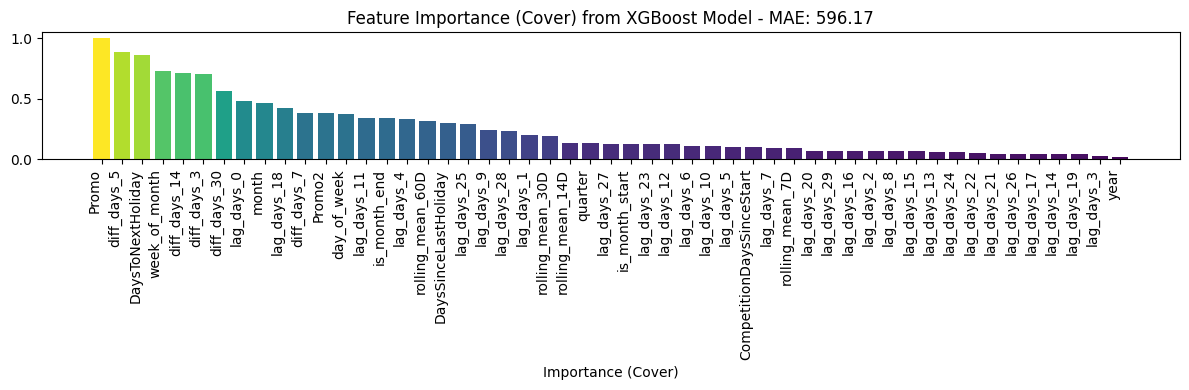

In [9]:
# Extract feature importance from the booster and plot it
importance = booster.get_score(importance_type='cover')

importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values(by='importance', ascending=False)

importance_df['importance'] = importance_df['importance'] / importance_df['importance'].max()  # Normalize to sum to 1

from sklearn.metrics import  mean_absolute_error
mae = mean_absolute_error(results["Sales_actual"], results["Sales_predicted"])

plt.figure(figsize=(12, 4))
plt.bar(importance_df['feature'], importance_df['importance'], color=cm.viridis(importance_df['importance']))
plt.xlabel('Importance (Cover)')
plt.title('Feature Importance (Cover) from XGBoost Model - MAE: {:.2f}'.format(mae))
plt.xticks(rotation=90, ha='right')
plt.tight_layout()

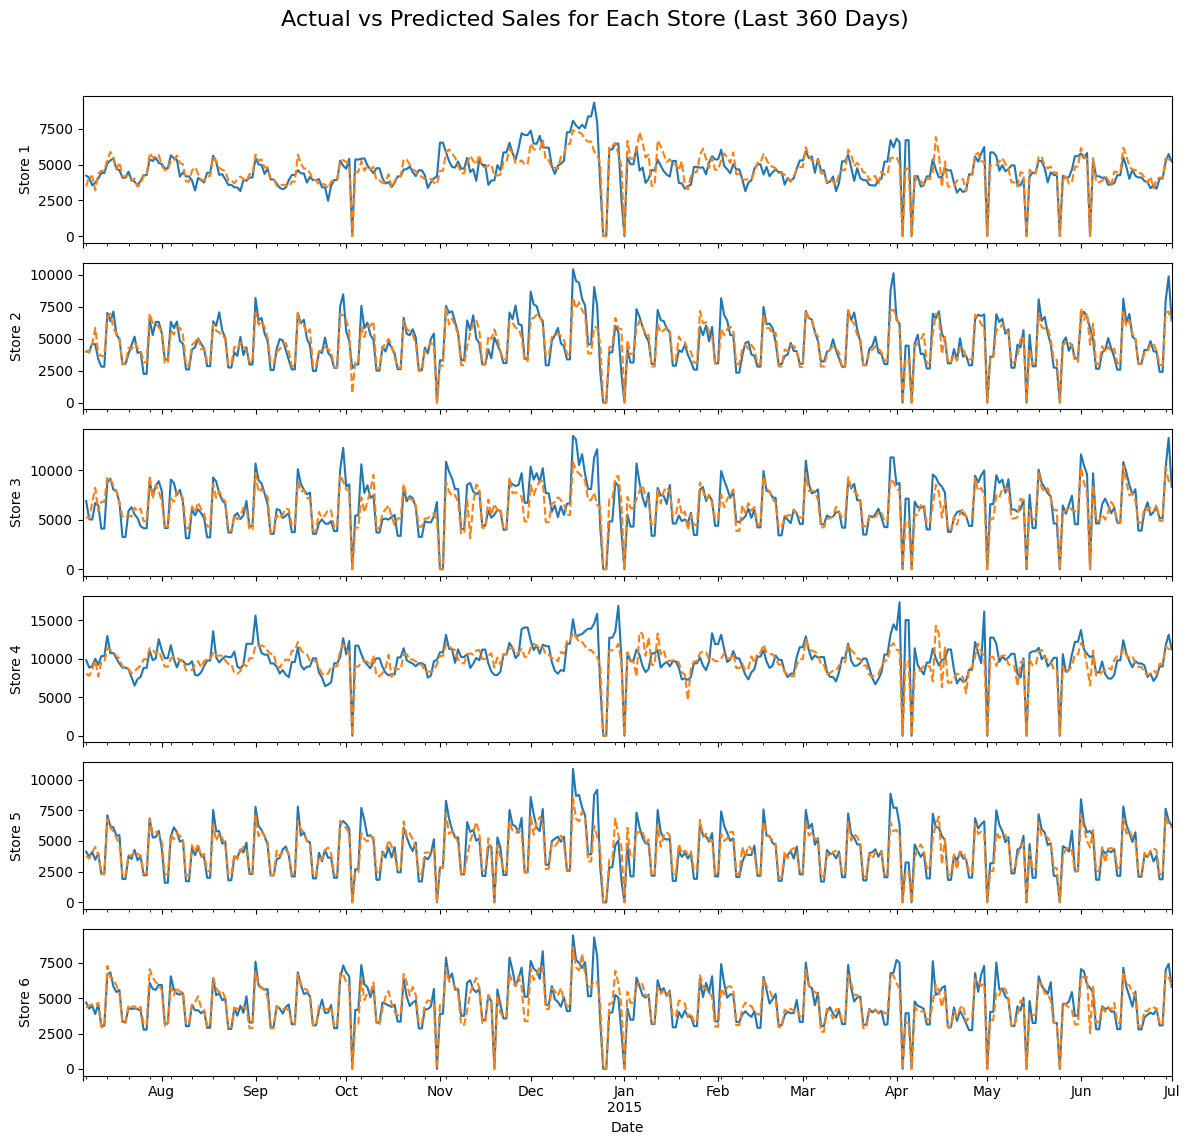

In [10]:
import matplotlib.pyplot as plt

n_days_to_plot = 360
n_days_offset  = 1*30  # Offset to start plotting from 3 months ago

max_date = results.index.get_level_values("Date").max() - pd.Timedelta(days=n_days_offset)
min_date = max_date - pd.Timedelta(days=n_days_to_plot)

actuals_recent = results.loc[(slice(None), slice(min_date, max_date)), 'Sales_actual']
preds_recent   = results.loc[(slice(None), slice(min_date, max_date)), 'Sales_predicted']

stores = actuals_recent.index.get_level_values("Store").unique()

fig, ax = plt.subplots(figsize=(12, 2 * len(stores)), nrows=len(stores), sharex=True, sharey=False)

for i, store in enumerate(stores):

    actual_store_sales    = actuals_recent.loc[(store, slice(None))].copy()
    predicted_store_sales = preds_recent.loc[(store, slice(None))].copy()
    
    closed_days = actual_store_sales.index.get_level_values("Date").day_name() == 'Sunday'
    closed_days = actual_store_sales[closed_days].index.get_level_values("Date")
    actual_store_sales[closed_days]    = np.nan  # Set closed days to NaN for plotting
    predicted_store_sales[closed_days] = np.nan  # Set closed days to NaN for plotting

    actual_store_sales.fillna(method='ffill', inplace=True)  # Forward fill to maintain continuity in the plot
    predicted_store_sales.fillna(method='ffill', inplace=True)  # Forward fill to maintain continuity in the plot


    actual_store_sales.plot(label=f"Actual", ax=ax[i])
    predicted_store_sales.plot(label=f"Predicted", ax=ax[i], linestyle='--')

    #ax[i].legend()
    ax[i].set_ylabel("Store {}".format(store))
    ax[i].set_xlabel("Date")
plt.suptitle("Actual vs Predicted Sales for Each Store (Last {} Days)".format(n_days_to_plot), fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle